# Tutorial 6: Mixed Precision Quantization Search with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [2]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can load the Bert checkpoint directly from HuggingFace.

In [3]:
from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


If you have previously ran the tutorial on Neural Architecture Search (NAS), run the following cell to import the best model obtained from the search process.

In [4]:
from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [5]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads.

In [6]:
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

search_space = {
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_categorical` function, which triggers the chosen sampler to choose a layer type. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [7]:
from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial):

    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # If the chosen layer is integer, define the low precision config
            if new_layer_cls == LinearInteger:
                kwargs["config"] = {
                    "data_in_width": 8,
                    "data_in_frac_width": 4,
                    "weight_width": 8,
                    "weight_frac_width": 4,
                    "bias_width": 8,
                    "bias_frac_width": 4,
                }
            # elif... (other precisions)

            # Create the new layer (copy the weights)
            new_layer = new_layer_cls(**kwargs)
            new_layer.weight.data = layer.weight.data

            # Replace the layer in the model
            deepsetattr(trial_model, name, new_layer)

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [8]:
from chop.tools import get_trainer
import random


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [9]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [10]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=1,
    timeout=60 * 60 * 24,
)

[I 2026-02-06 11:25:59,001] A new study created in memory with name: bert-tiny-nas-study
/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  optuna_warn(message)
/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  optuna_warn(message)
/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be

Step,Training Loss
500,0.349600
1000,0.337700
1500,0.359100
2000,0.350600
2500,0.349300
3000,0.365700


[I 2026-02-06 11:28:20,814] Trial 0 finished with value: 0.87404 and parameters: {'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'classifier_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>}. Best is trial 0 with value: 0.87404.


# Question 1

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

search_space_task1 = {
    "linear_layer_choices": [torch.nn.Linear, LinearInteger],
    "widths": [8, 16, 32],
    "frac_widths": [2, 4, 8]
}

def construct_model_task1(trial):
    trial_model = deepcopy(base_model)
    
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(f"{name}_type", search_space_task1["linear_layer_choices"])
            
            if new_layer_cls == torch.nn.Linear:
                continue
                
            w_width = trial.suggest_categorical(f"{name}_w_width", search_space_task1["widths"])
            f_width = trial.suggest_categorical(f"{name}_f_width", search_space_task1["frac_widths"])
            
            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
                "config": {
                    "weight_width": w_width,
                    "weight_frac_width": f_width,
                    "data_in_width": w_width,
                    "data_in_frac_width": f_width,
                    "bias_width": w_width,
                    "bias_frac_width": f_width,
                }
            }
            
            new_layer = new_layer_cls(**kwargs)
            new_layer.weight.data = layer.weight.data
            deepsetattr(trial_model, name, new_layer)
            
    return trial_model

def objective_task1(trial):
    model = construct_model_task1(trial)
    trainer = get_trainer(model=model, tokenized_dataset=dataset, tokenizer=tokenizer, 
                         evaluate_metric="accuracy", num_train_epochs=1)
    trainer.train()
    return trainer.evaluate()["eval_accuracy"]

study_task1 = optuna.create_study(direction="maximize")
study_task1.optimize(objective_task1, n_trials=20) 

df = study_task1.trials_dataframe()
df['running_max'] = df['value'].cummax()

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['running_max'], marker='o', linestyle='-')
plt.xlabel("Trial Number")
plt.ylabel("Maximum Accuracy Achieved")
plt.title("Task 1: Search Progress with Variable Bit-Widths")
plt.grid(True)
plt.show()

# Question 2

[I 2026-02-06 14:10:18,139] A new study created in memory with name: bert_Integer


Starting Comparative Precision Search...
--- Running search for: Integer ---


/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  optuna_warn(message)
/home/qduff/Downloads/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib64/python3.13/site-packages/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


[I 2026-02-06 14:12:56,522] Trial 0 finished with value: 0.5 and parameters: {'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.key_int_w': 4, 'bert.encoder.layer.0.attention.self.key_int_f': 4, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_int_w': 8, 'bert.encoder.layer.0.intermediate.dense_int_f': 2, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.output.dense_int_w': 4, 'bert.encoder.layer.0.output.dense_int_f': 2, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_int_w': 4, 'bert.encoder.layer.1.attention.output.dense_int_f': 2, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear

...

[I 2026-02-06 15:58:47,902] Trial 3 finished with value: 0.5 and parameters: {'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.attention.self.key_log_w': 4, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.intermediate.dense_log_w': 8, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.output.dense_log_w': 4, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.attention.output.dense_log_w': 8, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.intermediate.dense_log_w': 4, 'bert.encoder.layer.1.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.output.dense_log_w': 4, 'bert.pooler.d

Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


[I 2026-02-06 16:01:56,223] Trial 4 finished with value: 0.5 and parameters: {'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.attention.self.key_log_w': 8, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.intermediate.dense_log_w': 4, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.output.dense_log_w': 8, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.attention.output.dense_log_w': 4, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.intermediate.dense_log_w': 4, 'bert.encoder.layer.1.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.output.dense_log_w': 8, 'bert.pooler.d

Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


[I 2026-02-06 16:05:05,404] Trial 5 finished with value: 0.5 and parameters: {'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.attention.self.key_log_w': 8, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.intermediate.dense_log_w': 8, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.output.dense_log_w': 8, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.attention.output.dense_log_w': 8, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.intermediate.dense_log_w': 4, 'bert.encoder.layer.1.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.1.output.dense_log_w': 4, 'bert.pooler.d

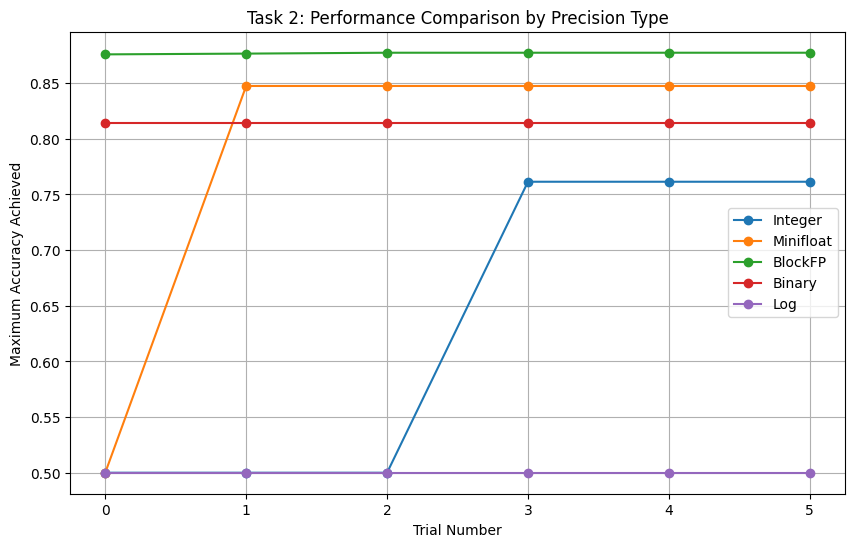

In [ ]:
import torch
import optuna
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy
from chop.tools import get_trainer
from chop.tools.utils import deepsetattr

from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatIEEE,
    LinearMinifloatDenorm,
    LinearBlockFP,
    LinearBinary,
    LinearLog,
)

def get_config_for_layer(trial, name, layer_cls):
    if layer_cls == LinearInteger:
        w = trial.suggest_categorical(f"{name}_int_w", [4, 8])
        f = trial.suggest_categorical(f"{name}_int_f", [2, 4])
        return {
            "weight_width": w, "weight_frac_width": f,
            "data_in_width": w, "data_in_frac_width": f,
            "bias_width": w, "bias_frac_width": f
        }

    elif layer_cls in [LinearMinifloatIEEE, LinearMinifloatDenorm]:
        w = trial.suggest_categorical(f"{name}_flt_w", [4, 8])
        exp = w // 2
        man = w - 1 - exp
        bias = 2 ** (exp - 1) - 1
        return {
            "weight_width": w, "weight_exponent_width": exp, "weight_mantissa_width": man, "weight_exponent_bias": bias,
            "data_in_width": w, "data_in_exponent_width": exp, "data_in_mantissa_width": man, "data_in_exponent_bias": bias,
            "bias_width": w, "bias_exponent_width": exp, "bias_mantissa_width": man, "bias_exponent_bias": bias
        }

    elif layer_cls == LinearBlockFP:
        w = trial.suggest_categorical(f"{name}_blk_w", [8, 16])
        exp = 4 
        man = w - 1 - exp
        bias = 2 ** (exp - 1) - 1
        block_size = [1, 16]
        return {
            "weight_width": w, "weight_exponent_width": exp, "weight_mantissa_width": man, "weight_exponent_bias": bias, "weight_block_size": block_size,
            "data_in_width": w, "data_in_exponent_width": exp, "data_in_mantissa_width": man, "data_in_exponent_bias": bias, "data_in_block_size": block_size,
            "bias_width": w, "bias_exponent_width": exp, "bias_mantissa_width": man, "bias_exponent_bias": bias, "bias_block_size": block_size
        }
    
    elif layer_cls == LinearBinary:
        return {
            "weight_stochastic": False, "weight_bipolar": True,
            "data_in_stochastic": False, "data_in_bipolar": True,
            "bias_stochastic": False, "bias_bipolar": True
        }
    
    elif layer_cls == LinearLog:
         w = trial.suggest_categorical(f"{name}_log_w", [4, 8])
         # LinearLog requires exponent_bias keys to be present
         bias = 0
         return {
             "weight_width": w, "weight_exponent_bias": bias,
             "data_in_width": w, "data_in_exponent_bias": bias,
             "bias_width": w, "bias_exponent_bias": bias
         }

    return {}

# 3. Model Constructor
def construct_model_generic(trial, allowed_layer_types):
    trial_model = deepcopy(base_model)
    
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(f"{name}_type", allowed_layer_types)
            config = get_config_for_layer(trial, name, new_layer_cls)
            
            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
                "config": config
            }
            
            new_layer = new_layer_cls(**kwargs)
            if new_layer.weight.shape == layer.weight.shape:
                new_layer.weight.data = layer.weight.data
                if layer.bias is not None and new_layer.bias is not None:
                    new_layer.bias.data = layer.bias.data
            
            deepsetattr(trial_model, name, new_layer)
            
    return trial_model

precision_groups = {
    "Integer": [LinearInteger],
    "Minifloat": [LinearMinifloatIEEE, LinearMinifloatDenorm],
    "BlockFP": [LinearBlockFP],
    "Binary": [LinearBinary],
    "Log": [LinearLog]
}

results = {}

print("Starting Comparative Precision Search...")

# 5. Search Loop
for group_name, layer_classes in precision_groups.items():
    print(f"--- Running search for: {group_name} ---")
    
    def objective(trial):
        model = construct_model_generic(trial, layer_classes)
        
        # Using fewer epochs for tutorial speed
        trainer = get_trainer(
            model=model, 
            tokenized_dataset=dataset, 
            tokenizer=tokenizer,
            evaluate_metric="accuracy", 
            num_train_epochs=1
        )
        trainer.train()
        return trainer.evaluate()["eval_accuracy"]

    study = optuna.create_study(direction="maximize", study_name=f"bert_{group_name}")
    study.optimize(objective, n_trials=6) ## TODO increase
    
    df = study.trials_dataframe()
    df['running_max'] = df['value'].cummax()
    results[group_name] = df['running_max']

plt.figure(figsize=(10, 6))

for group_name, running_max in results.items():
    plt.plot(running_max.index, running_max, marker='o', linestyle='-', label=group_name)

plt.xlabel("Trial Number")
plt.ylabel("Maximum Accuracy Achieved")
plt.title("Task 2: Performance Comparison by Precision Type")
plt.legend()
plt.grid(True)
plt.show()